# Config B - Continuous-State ICU-Sepsis (Deep RL)

This notebook **only calls** the implementation in [`sepsis_rl.py`](sepsis_rl.py).
All the agent / training / evaluation / plotting logic lives there; here we just
run it and look at the results. Every figure is saved to the **`outputs/`** directory.

**Action space is `Discrete(25)`** (5 vasopressor x 5 IV-fluid levels) - the same as
Config A. What is continuous in Config B is the **observation** (47-dim clinical
feature vector). We therefore use the discrete-action algorithms **DQN, PPO, A2C**.

| Run | Normalization | Purpose |
|-----|---------------|---------|
| DQN, PPO (v1) | none | baseline on raw observations |
| DQN-v2, PPO-v2, A2C | VecNormalize | clean ablation: effect of obs normalization |

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import sepsis_rl as srl

srl.ensure_dirs(srl.OUTPUT_DIR, srl.MODELS_DIR, srl.LOGS_DIR)
print('Device           :', srl.DEVICE)
print('Plots saved to   :', srl.OUTPUT_DIR + '/')
print('Algorithms       :', list(srl.ALGOS))

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Device           : cuda
Plots saved to   : outputs/
Algorithms       : ['DQN', 'PPO', 'A2C']


## 1. Environment & random baseline

The full clinical environment (`make_clinical_env`) stacks three failure-mode
wrappers on top of the continuous base env: episodic observation noise, episodic
missing labs, and rare acute death events. The random policy is the target to beat.

In [2]:
from envs.wrappers import make_clinical_env

env = make_clinical_env()
print('Observation space:', env.observation_space)
print('Action space     :', env.action_space)
env.close()

# Random baseline (use 1000 episodes for the report)
random_stats = srl.random_baseline(n_episodes=1000)
RANDOM_RETURN = random_stats['return']

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Observation space: Box(-inf, inf, (47,), float32)
Action space     : Discrete(25)
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[random] return=0.5852  survival=67.9%


## 2. Training

`TIMESTEPS` controls the budget. Default is **fast** (a few minutes per agent).
For final, report-quality results set it to `1_000_000` (several hours total).

In [3]:
TIMESTEPS = 150_000      # <- para resultados finais usa 1_000_000
EVAL_FREQ = 5_000
N_EVAL    = 200           # aumentado de 50 para curvas mais suaves

# --- v1: raw observations (no normalization) ---
_, dqn_tag = srl.train_agent('DQN', timesteps=TIMESTEPS, normalize=False,
                             eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL)
_, ppo_tag = srl.train_agent('PPO', timesteps=TIMESTEPS, normalize=False,
                             eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

[dqn] training complete (150,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[ppo] training complete (150,000 steps).


### v2: with `VecNormalize`

The 47 features live on wildly different scales, so normalizing observations is the
single biggest lever for these agents. v2 changes **only** the normalization vs v1.

In [4]:
_, dqn2_tag = srl.train_agent('DQN', timesteps=TIMESTEPS, normalize=True,
                             eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL)
_, ppo2_tag = srl.train_agent('PPO', timesteps=TIMESTEPS, normalize=True,
                             eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL)
_, a2c_tag  = srl.train_agent('A2C', timesteps=TIMESTEPS, normalize=True,
                             eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[dqn_v2] training complete (150,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[ppo_v2] training complete (150,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[a2c_v2] training complete (150,000 steps).


## 3. Learning curves

Read from each run's `evaluations.npz`, EMA-smoothed (faint line = raw eval returns).

Saved outputs\configB_learning_curves.png


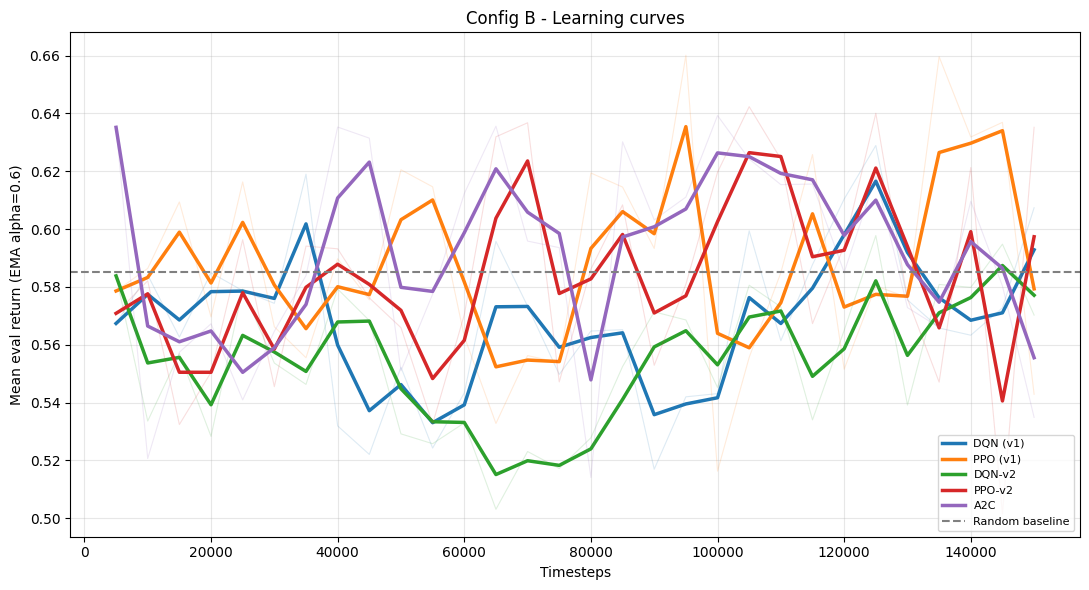

Saved outputs\configB_learning_curves_zoom.png


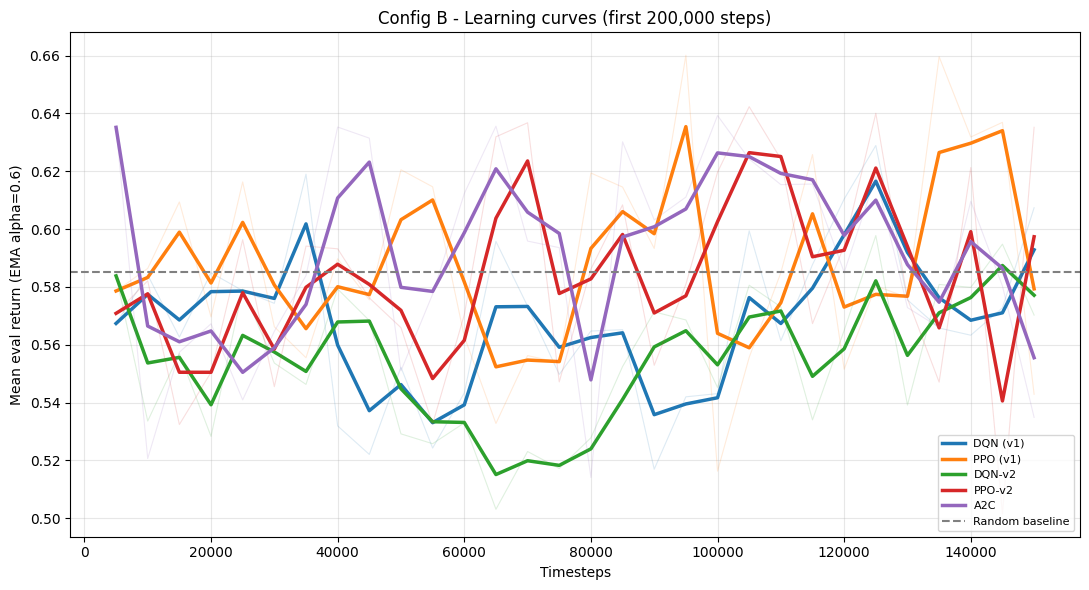

'outputs\\configB_learning_curves_zoom.png'

In [5]:
# Curva completa (todos os passos)
srl.plot_learning_curves(
    {dqn_tag: 'DQN (v1)', ppo_tag: 'PPO (v1)',
     dqn2_tag: 'DQN-v2', ppo2_tag: 'PPO-v2', a2c_tag: 'A2C'},
    baseline=RANDOM_RETURN,
)

# Zoom nos primeiros 200k passos - onde a aprendizagem acontece
srl.plot_learning_curves(
    {dqn_tag: 'DQN (v1)', ppo_tag: 'PPO (v1)',
     dqn2_tag: 'DQN-v2', ppo2_tag: 'PPO-v2', a2c_tag: 'A2C'},
    baseline=RANDOM_RETURN,
    zoom_steps=200_000,
    filename='configB_learning_curves_zoom.png',
)

## 4. Robustness evaluation

Each agent is evaluated on its own env per failure mode (Clean / Noisy / Missing /
Acute / All). Survival is read from the terminal reward (death -> 0, survival -> ~1).

In [6]:
N_EVAL_EPISODES = 1000     # 1000 for the report

results = {
    'DQN (v1)': srl.evaluate_conditions(dqn_tag,  'DQN', n_episodes=N_EVAL_EPISODES),
    'PPO (v1)': srl.evaluate_conditions(ppo_tag,  'PPO', n_episodes=N_EVAL_EPISODES),
    'DQN-v2':   srl.evaluate_conditions(dqn2_tag, 'DQN', n_episodes=N_EVAL_EPISODES),
    'PPO-v2':   srl.evaluate_conditions(ppo2_tag, 'PPO', n_episodes=N_EVAL_EPISODES),
    'A2C':      srl.evaluate_conditions(a2c_tag,  'A2C', n_episodes=N_EVAL_EPISODES),
}

srl.results_table(results, random_ret=RANDOM_RETURN, condition='All')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[dqn] All      n=1000  return=0.5742  survival=64.7%  intensity=0.392
[dqn] Clean    n= 679  return=0.6365  survival=70.8%  intensity=0.389
[dqn] Noisy    n= 139  return=0.5746  survival=65.5%  intensity=0.421
[dqn] Missing  n= 143  return=0.5813  survival=65.0%  intensity=0.394
[dqn] Acute    n=  84  return=-0.0733  survival=0.0%  intensity=0.377
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[ppo] All      n=1000  return=0.5898  survival=66.0%  intensity=0.406
[ppo] Clean    n= 664  return=0.6479  survival=71.7%  intensity=0.405
[ppo] Noisy    n= 159  return=0.5941  survival=65.4%  intensity=0.404
[ppo] Missing  n= 150  return=0.5831  survival=66.7%  intensity=0.409
[ppo] Acute    n=  74  return=-0.0680  survival=0.0%  intensity=0.400
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bia

,Agent,Return (All),Survival (All),Intensity (All),vs Random
0,DQN (v1),0.5742,64.7%,0.392,-1.9%
1,PPO (v1),0.5898,66.0%,0.406,+0.8%
2,DQN-v2,0.5590,65.1%,0.443,-4.5%
3,PPO-v2,0.5945,66.2%,0.407,+1.6%
4,A2C,0.6012,66.4%,0.374,+2.7%


Saved outputs\configB_robustness_return.png


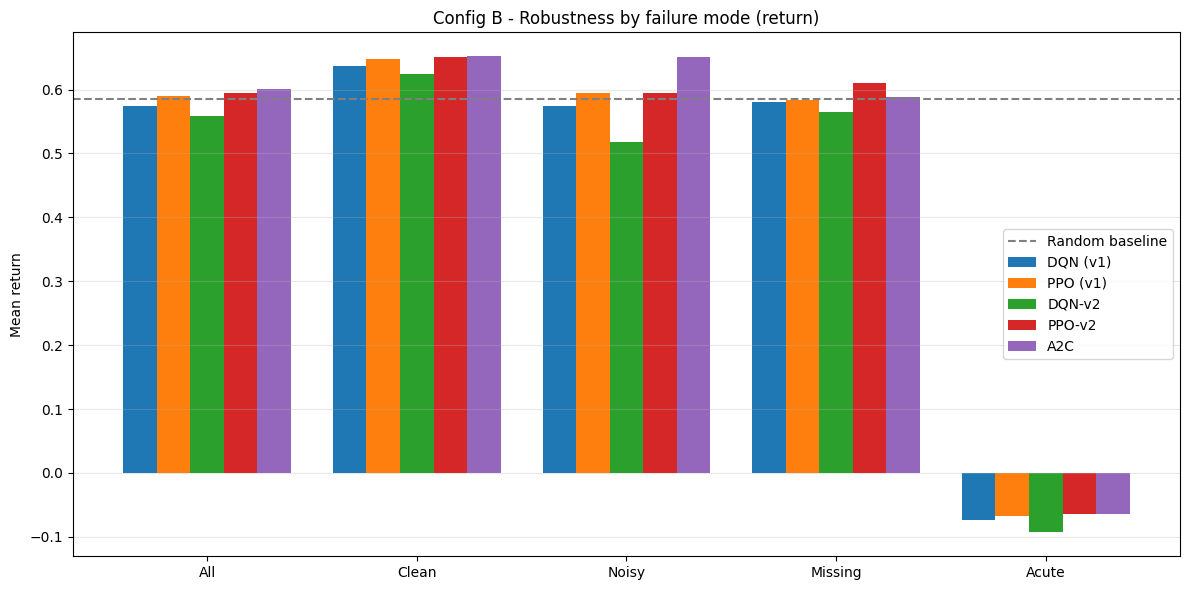

Saved outputs\configB_robustness_survival.png


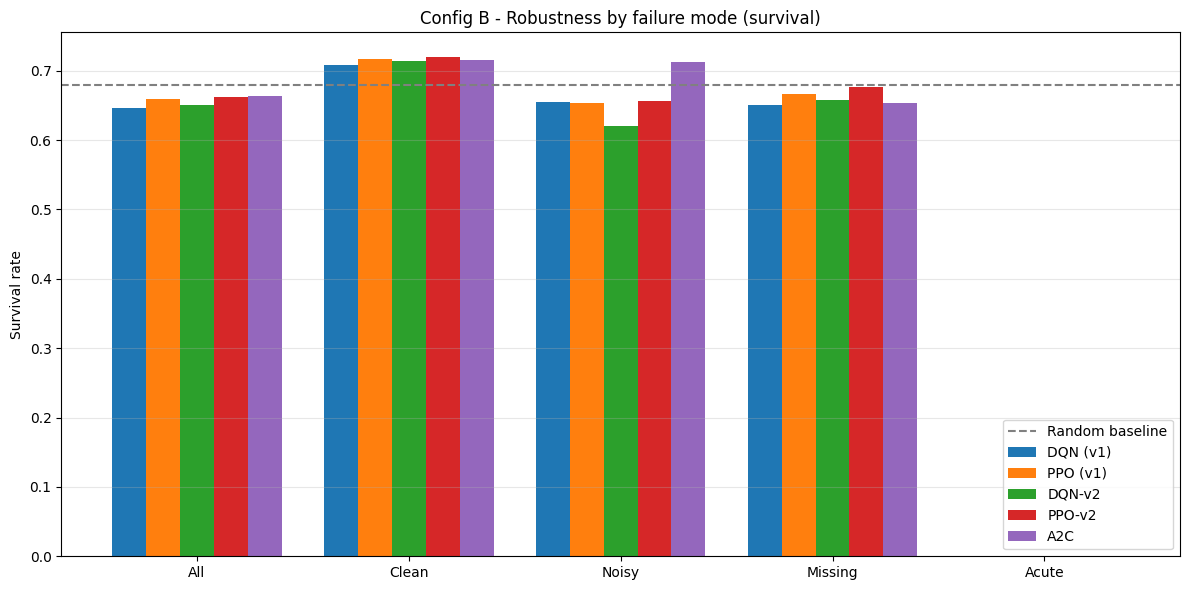

'outputs\\configB_robustness_survival.png'

In [7]:
srl.plot_robustness(results, metric='return',   baseline=RANDOM_RETURN,
                    filename='configB_robustness_return.png')
srl.plot_robustness(results, metric='survival', baseline=random_stats['survival'],
                    filename='configB_robustness_survival.png')

## 5. Optional hyperparameter tuning (Optuna)

This section is intentionally disabled by default so the notebook can run end-to-end in a reasonable time. Set `RUN_OPTUNA=True` to run the short proxy search, and set `RUN_TUNED=True` only after Optuna if you want full-budget tuned training.


[I 2026-06-03 03:33:25,842] A new study created in memory with name: DQN_configB


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[dqn_optuna_t0] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-06-03 03:34:10,864] Trial 0 finished with value: 0.40800000000000003 and parameters: {'learning_rate': 2.3058447658736643e-05, 'buffer_size': 50000, 'batch_size': 256, 'train_freq': 4, 'exploration_fraction': 0.34834015210328806, 'target_update_interval': 500}. Best is trial 0 with value: 0.40800000000000003.


[dqn_optuna_t0] All      n=  50  return=0.4080  survival=52.0%  intensity=0.439
[dqn_optuna_t0] Clean    n=  26  return=0.5667  survival=65.4%  intensity=0.443
[dqn_optuna_t0] Noisy    n=  10  return=0.4840  survival=60.0%  intensity=0.392
[dqn_optuna_t0] Missing  n=  12  return=0.3004  survival=41.7%  intensity=0.445
[dqn_optuna_t0] Acute    n=   8  return=-0.1641  survival=0.0%  intensity=0.446
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[dqn_optuna_t1] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-06-03 03:34:57,722] Trial 1 finished with value: 0.53525 and parameters: {'learning_rate': 1.5768375317151475e-05, 'buffer_size': 100000, 'batch_size': 128, 'train_freq': 4, 'exploration_fraction': 0.1207536639574994, 'target_update_interval': 2000}. Best is trial 1 with value: 0.53525.


...

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[dqn_optuna_t13] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[dqn_optuna_t13] All      n=  50  return=0.4304  survival=52.0%  intensity=0.421
[dqn_optuna_t13] Clean    n=  32  return=0.5409  survival=62.5%  intensity=0.409
[dqn_optuna_t13] Noisy    n=   5  return=0.5150  survival=60.0%  intensity=0.486
[dqn_optuna_t13] Missing  n=   9  return=0.2119  survival=33.3%  intensity=0.443
[dqn_optuna_t13] Acute    n=   5  return=-0.0540  survival=0.0%  intensity=0.337


[I 2026-06-03 03:46:48,045] Trial 13 finished with value: 0.43040000000000006 and parameters: {'learning_rate': 8.212197323615246e-05, 'buffer_size': 100000, 'batch_size': 128, 'train_freq': 4, 'exploration_fraction': 0.20894785278582892, 'target_update_interval': 2000}. Best is trial 1 with value: 0.53525.


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[dqn_optuna_t14] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[dqn_optuna_t14] All      n=  50  return=0.4420  survival=54.0%  intensity=0.482
[dqn_optuna_t14] Clean    n=  31  return=0.4522  survival=54.8%  intensity=0.497
[dqn_optuna_t14] Noisy    n=   6  return=0.3717  survival=50.0%  intensity=0.552
[dqn_optuna_t14] Missing  n=  11  return=0.6343  survival=72.7%  intensity=0.432
[dqn_optuna_t14] Acute    n=   6  return=-0.0896  survival=0.0%  intensity=0.448


[I 2026-06-03 03:47:32,720] Trial 14 finished with value: 0.44205 and parameters: {'learning_rate': 6.226237613549072e-05, 'buffer_size': 100000, 'batch_size': 128, 'train_freq': 4, 'exploration_fraction': 0.22289066437349384, 'target_update_interval': 2000}. Best is trial 1 with value: 0.53525.



[DQN] Best value: 0.5353
[DQN] Best params: {'learning_rate': 1.5768375317151475e-05, 'buffer_size': 100000, 'batch_size': 128, 'train_freq': 4, 'exploration_fraction': 0.1207536639574994, 'target_update_interval': 2000}
Saved outputs\optuna_dqn_history.png


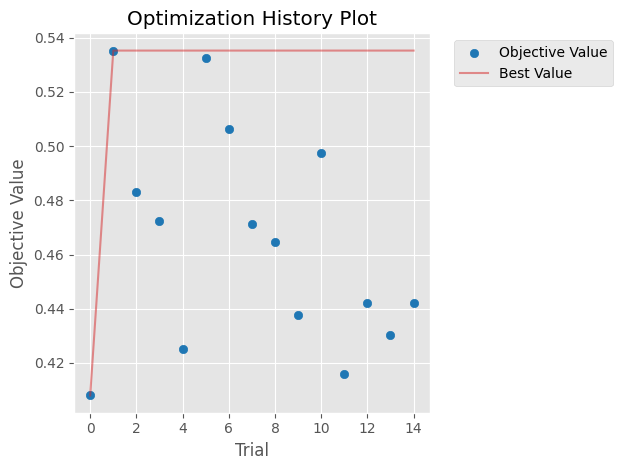

Saved outputs\optuna_dqn_importance.png


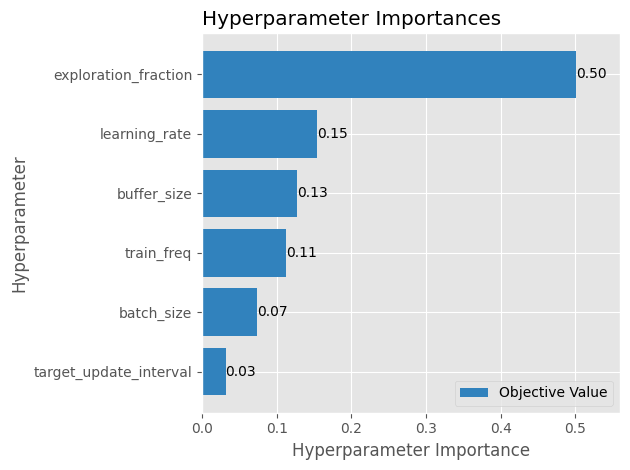

[I 2026-06-03 03:47:33,586] A new study created in memory with name: PPO_configB


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[ppo_optuna_t0] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-06-03 03:48:48,145] Trial 0 finished with value: 0.42345 and parameters: {'n_steps': 1024, 'learning_rate': 4.3034939563102804e-05, 'batch_size': 128, 'gae_lambda': 0.9055018344833919, 'clip_range': 0.1, 'ent_coef': 0.0010841771132219316}. Best is trial 0 with value: 0.42345.


[ppo_optuna_t0] All      n=  50  return=0.4234  survival=50.0%  intensity=0.386
[ppo_optuna_t0] Clean    n=  35  return=0.4030  survival=48.6%  intensity=0.402
[ppo_optuna_t0] Noisy    n=   6  return=0.4288  survival=50.0%  intensity=0.411
[ppo_optuna_t0] Missing  n=   9  return=0.6086  survival=66.7%  intensity=0.363
[ppo_optuna_t0] Acute    n=   2  return=-0.0788  survival=0.0%  intensity=0.219
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[ppo_optuna_t1] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-06-03 03:50:19,466] Trial 1 finished with value: 0.5083 and parameters: {'n_steps': 1024, 'learning_rate': 0.0004263617337747656, 'batch_size': 64, 'gae_lambda': 0.9123863230788991, 'clip_range': 0.2, 'ent_coef': 0.04521908060770885}. Best is trial 1 with value: 0.5083.


...

[ppo_optuna_t12] All      n=  50  return=0.5020  survival=62.0%  intensity=0.529
[ppo_optuna_t12] Clean    n=  35  return=0.4786  survival=60.0%  intensity=0.520
[ppo_optuna_t12] Noisy    n=   6  return=0.5925  survival=66.7%  intensity=0.615
[ppo_optuna_t12] Missing  n=  10  return=0.6850  survival=80.0%  intensity=0.559
[ppo_optuna_t12] Acute    n=   1  return=-0.1250  survival=0.0%  intensity=0.286
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[ppo_optuna_t13] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-06-03 04:06:42,813] Trial 13 finished with value: 0.5045999999999999 and parameters: {'n_steps': 256, 'learning_rate': 0.0001355923027938491, 'batch_size': 64, 'gae_lambda': 0.9001718402341676, 'clip_range': 0.2, 'ent_coef': 0.049204956575361204}. Best is trial 7 with value: 0.5556.


[ppo_optuna_t13] All      n=  50  return=0.5046  survival=62.0%  intensity=0.582
[ppo_optuna_t13] Clean    n=  28  return=0.6067  survival=71.4%  intensity=0.542
[ppo_optuna_t13] Noisy    n=   6  return=0.2017  survival=33.3%  intensity=0.604
[ppo_optuna_t13] Missing  n=  15  return=0.4625  survival=60.0%  intensity=0.627
[ppo_optuna_t13] Acute    n=   6  return=-0.0933  survival=0.0%  intensity=0.682
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[ppo_optuna_t14] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-06-03 04:08:08,761] Trial 14 finished with value: 0.4454000000000001 and parameters: {'n_steps': 1024, 'learning_rate': 0.0002955638735783931, 'batch_size': 64, 'gae_lambda': 0.9512441026434636, 'clip_range': 0.2, 'ent_coef': 0.009889491643483945}. Best is trial 7 with value: 0.5556.


[ppo_optuna_t14] All      n=  50  return=0.4454  survival=54.0%  intensity=0.433
[ppo_optuna_t14] Clean    n=  35  return=0.5541  survival=65.7%  intensity=0.414
[ppo_optuna_t14] Noisy    n=   8  return=0.3066  survival=37.5%  intensity=0.422
[ppo_optuna_t14] Missing  n=   5  return=0.1575  survival=20.0%  intensity=0.563
[ppo_optuna_t14] Acute    n=   6  return=-0.1067  survival=0.0%  intensity=0.499

[PPO] Best value: 0.5556
[PPO] Best params: {'n_steps': 256, 'learning_rate': 3.3554229715301134e-05, 'batch_size': 64, 'gae_lambda': 0.9149444660908979, 'clip_range': 0.2, 'ent_coef': 0.047892966824816245}
Saved outputs\optuna_ppo_history.png


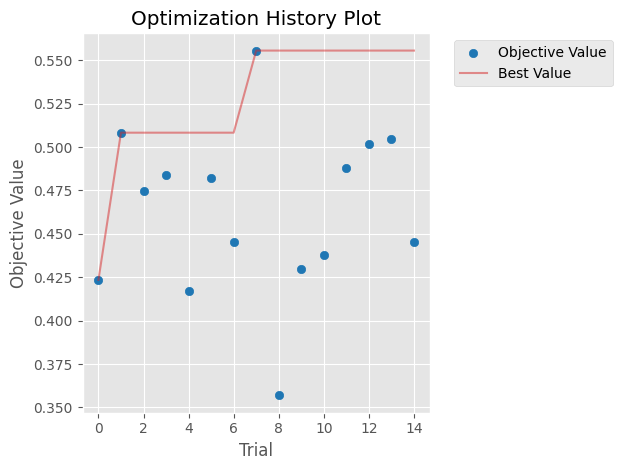

Saved outputs\optuna_ppo_importance.png


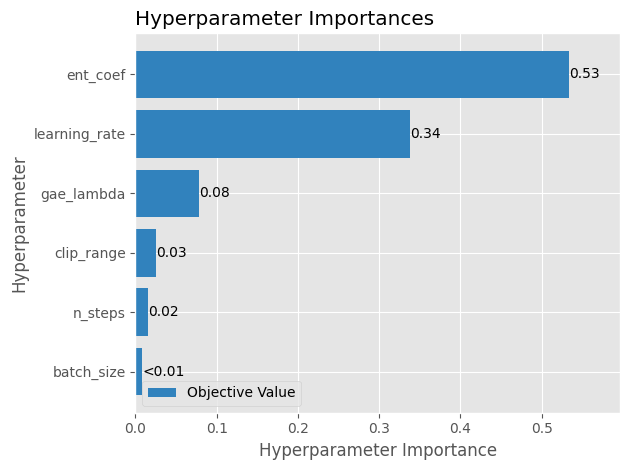

[I 2026-06-03 04:08:09,125] A new study created in memory with name: A2C_configB


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[a2c_optuna_t0] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-06-03 04:09:19,065] Trial 0 finished with value: 0.46975 and parameters: {'learning_rate': 0.0023397769226921375, 'n_steps': 16, 'gae_lambda': 0.9271705607250215, 'ent_coef': 0.031654118669520774}. Best is trial 0 with value: 0.46975.


[a2c_optuna_t0] All      n=  50  return=0.4698  survival=56.0%  intensity=0.440
[a2c_optuna_t0] Clean    n=  32  return=0.5891  survival=68.8%  intensity=0.441
[a2c_optuna_t0] Noisy    n=   7  return=0.4825  survival=57.1%  intensity=0.456
[a2c_optuna_t0] Missing  n=  11  return=0.3836  survival=45.5%  intensity=0.466
[a2c_optuna_t0] Acute    n=   6  return=-0.0525  survival=0.0%  intensity=0.373
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[a2c_optuna_t1] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-06-03 04:10:29,176] Trial 1 finished with value: 0.45485 and parameters: {'learning_rate': 0.0017727483495335655, 'n_steps': 16, 'gae_lambda': 0.9551669897064433, 'ent_coef': 0.0009385391974004319}. Best is trial 0 with value: 0.46975.


...

[a2c_optuna_t12] All      n=  50  return=0.4571  survival=50.0%  intensity=0.239
[a2c_optuna_t12] Clean    n=  27  return=0.5816  survival=63.0%  intensity=0.256
[a2c_optuna_t12] Noisy    n=  12  return=0.2952  survival=33.3%  intensity=0.217
[a2c_optuna_t12] Missing  n=  13  return=0.5865  survival=61.5%  intensity=0.208
[a2c_optuna_t12] Acute    n=   6  return=-0.0321  survival=0.0%  intensity=0.307
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[a2c_optuna_t13] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-06-03 04:27:01,937] Trial 13 finished with value: 0.5913999999999999 and parameters: {'learning_rate': 0.008863396742081036, 'n_steps': 5, 'gae_lambda': 0.9428858416351346, 'ent_coef': 0.006710647141527122}. Best is trial 13 with value: 0.5913999999999999.


[a2c_optuna_t13] All      n=  50  return=0.5914  survival=64.0%  intensity=0.211
[a2c_optuna_t13] Clean    n=  33  return=0.4963  survival=54.5%  intensity=0.246
[a2c_optuna_t13] Noisy    n=  11  return=0.8589  survival=90.9%  intensity=0.121
[a2c_optuna_t13] Missing  n=   6  return=0.7921  survival=83.3%  intensity=0.161
[a2c_optuna_t13] Acute    n=   1  return=-0.0075  survival=0.0%  intensity=0.150
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[a2c_optuna_t14] training complete (50,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[I 2026-06-03 04:28:21,345] Trial 14 finished with value: 0.47015 and parameters: {'learning_rate': 0.0006018932547130865, 'n_steps': 8, 'gae_lambda': 0.9637055218176105, 'ent_coef': 0.006239504034698563}. Best is trial 13 with value: 0.5913999999999999.


[a2c_optuna_t14] All      n=  50  return=0.4702  survival=52.0%  intensity=0.251
[a2c_optuna_t14] Clean    n=  36  return=0.5074  survival=55.6%  intensity=0.249
[a2c_optuna_t14] Noisy    n=   6  return=0.5946  survival=66.7%  intensity=0.301
[a2c_optuna_t14] Missing  n=   8  return=0.3334  survival=37.5%  intensity=0.224
[a2c_optuna_t14] Acute    n=   2  return=0.0000  survival=0.0%  intensity=0.125

[A2C] Best value: 0.5914
[A2C] Best params: {'learning_rate': 0.008863396742081036, 'n_steps': 5, 'gae_lambda': 0.9428858416351346, 'ent_coef': 0.006710647141527122}
Saved outputs\optuna_a2c_history.png


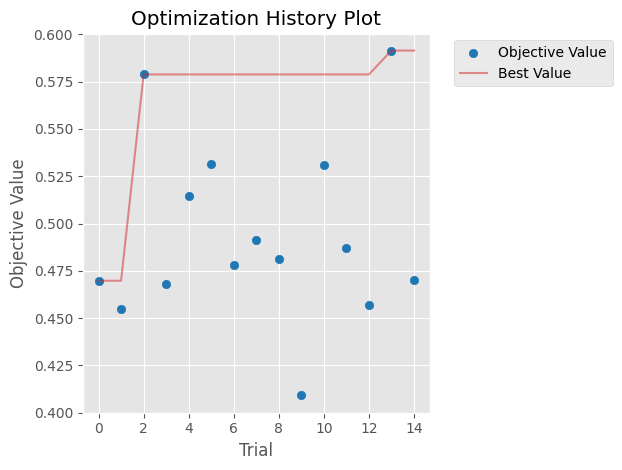

Saved outputs\optuna_a2c_importance.png


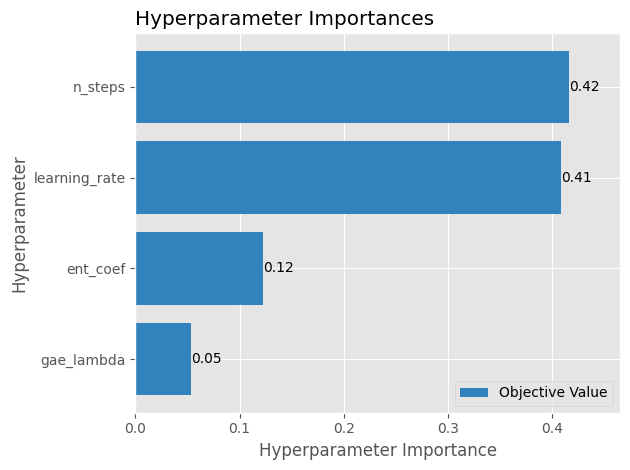

DQN: best return=0.5353  params={'learning_rate': 1.5768375317151475e-05, 'buffer_size': 100000, 'batch_size': 128, 'train_freq': 4, 'exploration_fraction': 0.1207536639574994, 'target_update_interval': 2000}
PPO: best return=0.5556  params={'n_steps': 256, 'learning_rate': 3.3554229715301134e-05, 'batch_size': 64, 'gae_lambda': 0.9149444660908979, 'clip_range': 0.2, 'ent_coef': 0.047892966824816245}
A2C: best return=0.5914  params={'learning_rate': 0.008863396742081036, 'n_steps': 5, 'gae_lambda': 0.9428858416351346, 'ent_coef': 0.006710647141527122}
Best params saved to optuna_best_params.json


In [ ]:
RUN_OPTUNA = False  # Set True only when you want the extra hyperparameter-search run.
studies = {}

if RUN_OPTUNA:
    for algo in ["DQN", "PPO", "A2C"]:
        studies[algo] = srl.tune(algo, n_trials=15, timesteps=50_000, normalize=True)
        srl.save_optuna_plots(studies[algo], name=algo)

    for algo, study in studies.items():
        print(f"{algo}: best return={study.best_value:.4f}  params={study.best_params}")

    import json as _json
    with open("optuna_best_params.json", "w") as f:
        _json.dump({algo: study.best_params for algo, study in studies.items()}, f, indent=2)
    print("Best params saved to optuna_best_params.json")
else:
    print("Optuna skipped. Set RUN_OPTUNA=True for the optional hyperparameter search.")


In [9]:
if RUN_OPTUNA:
    srl.plot_best_trial_curves(
        ['DQN', 'PPO', 'A2C'],
        baseline=RANDOM_RETURN,
    )
else:
    print("Best-trial curve skipped because RUN_OPTUNA=False.")


Best-trial curve skipped because RUN_OPTUNA=False.


### Optional full-budget retraining

Plug Optuna's best hyperparameters into a full-budget run. This is disabled by default because it can take several hours.


In [10]:
RUN_TUNED = False  # Set True after RUN_OPTUNA=True if you want full-budget tuned training.
TIMESTEPS_TUNED = 1_000_000

tuned_tags = {}

if RUN_TUNED:
    if not studies:
        raise RuntimeError("Run Optuna first: set RUN_OPTUNA=True and execute the tuning cell.")

    for best_algo in ['DQN', 'PPO', 'A2C']:
        best_hp = dict(studies[best_algo].best_params)
        _, tag = srl.train_agent(
            best_algo, timesteps=TIMESTEPS_TUNED, normalize=True,
            hyperparams=best_hp, tag=f'{best_algo.lower()}_tuned',
            eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL,
        )
        tuned_tags[best_algo] = tag

    srl.plot_learning_curves(
        {tuned_tags["DQN"]: "DQN (tuned)",
         tuned_tags["PPO"]: "PPO (tuned)",
         tuned_tags["A2C"]: "A2C (tuned)"},
        baseline=RANDOM_RETURN,
        zoom_steps=TIMESTEPS_TUNED,
        filename="configB_all_tuned_curves.png",
    )

    srl.plot_learning_curves(
        {tuned_tags["DQN"]: "DQN (tuned)",
         tuned_tags["PPO"]: "PPO (tuned)",
         tuned_tags["A2C"]: "A2C (tuned)"},
        baseline=RANDOM_RETURN,
        zoom_steps=300_000,
        filename="configB_all_tuned_curves_zoom.png",
    )

    results_tuned = {
        f"{algo} (tuned)": srl.evaluate_conditions(tag, algo, n_episodes=N_EVAL_EPISODES)
        for algo, tag in tuned_tags.items()
    }
    display(srl.results_table(results_tuned, random_ret=RANDOM_RETURN))
    srl.plot_robustness(results_tuned, metric="return", baseline=RANDOM_RETURN,
                        filename="configB_tuned_robustness.png")
else:
    print("Full-budget tuned training skipped. Set RUN_TUNED=True after running Optuna.")


Full-budget tuned training skipped. Set RUN_TUNED=True after running Optuna.


In [11]:
if tuned_tags:
    for algo, tag in tuned_tags.items():
        srl.plot_learning_curves(
            {tag: f"{algo} (tuned)"},
            baseline=RANDOM_RETURN,
            show_trend=True,
            filename=f"configB_{algo.lower()}_tuned_trend.png",
        )
else:
    print("Tuned trend plots skipped because RUN_TUNED=False.")


Tuned trend plots skipped because RUN_TUNED=False.


In [12]:
if tuned_tags:
    srl.plot_curves_grid(
        {'dqn_tuned': 'DQN (tuned)',
         'ppo_tuned': 'PPO (tuned)',
         'a2c_tuned': 'A2C (tuned)'},
        baseline=RANDOM_RETURN,
        filename='configB_tuned_grid.png',
    )
else:
    print("Tuned grid plot skipped because RUN_TUNED=False.")


Tuned grid plot skipped because RUN_TUNED=False.


## 6. Creative extension - robustness + clinical interpretability

Our creative extension audits the trained agents along two clinical axes:

1. **Robustness** under the three failure modes (Clean / Noisy / Missing / Acute) -
   already computed above via `evaluate_conditions` and `plot_robustness`.
2. **Interpretability**: (a) the *treatment-intensity* and *dose grid* each policy
   prescribes, and (b) *feature importance* of the DQN Q-network - which of the 47
   clinical variables actually drive its decisions.

This connects the learned policies back to clinical meaning (the whole point of the
`lam` parsimony penalty and the sepsis-severity features) and does so **without**
altering the required environment.

### 6.1 Treatment intensity & dose grid

Lower intensity at equal survival is clinically preferable. The 5x5 grid shows what each policy actually prescribes (vasopressor x IV fluid).

Saved outputs\configB_intensity.png


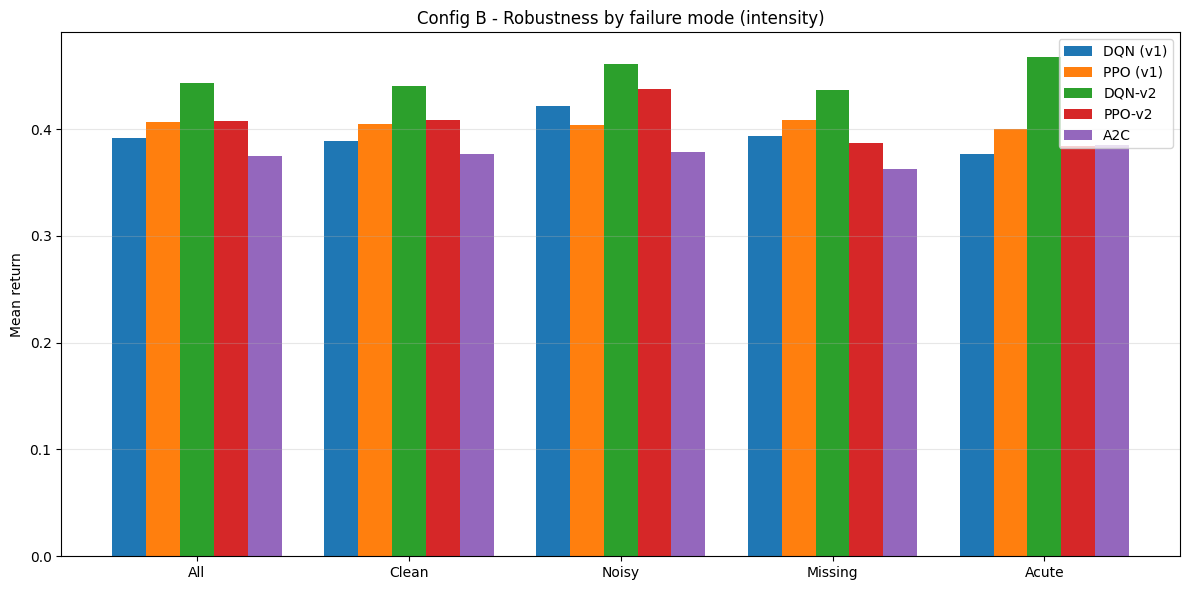

Saved outputs\configB_dose_grid.png


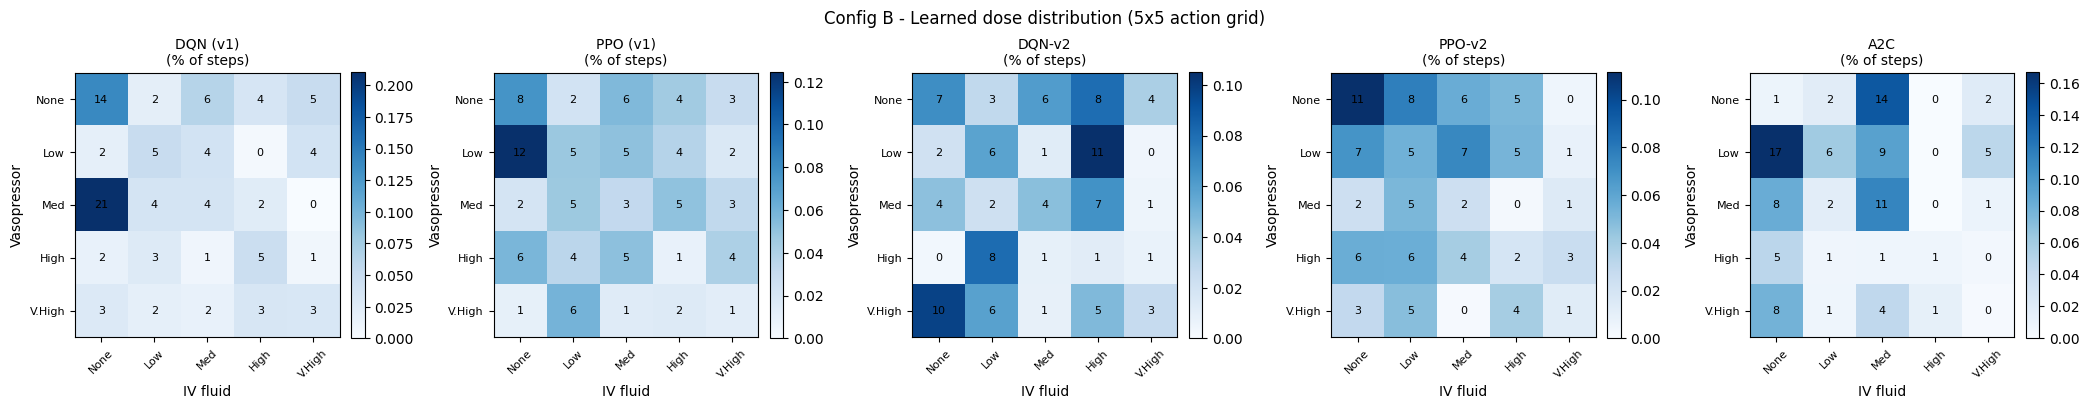

'outputs\\configB_dose_grid.png'

In [13]:
# Mean treatment intensity per failure mode (already collected during evaluation)
srl.plot_robustness(results, metric='intensity', baseline=None,
                    filename='configB_intensity.png')

# 5x5 dose grid (vasopressor x IV fluid) for every agent
srl.plot_dose_grid(results, filename='configB_dose_grid.png')

### 6.2 DQN feature importance (Q-value perturbation)

Permute each feature and measure the mean |Delta Q| on the chosen action. Red bars = established sepsis-severity markers; a credible agent should rely on them.

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Saved outputs\configB_feature_importance.png
Top 10 decision-relevant features:
   1. Milrinone        0.05153
   2. Weight           0.04409
   3. AST              0.04215
   4. Phenylephrine    0.04156
   5. Age              0.03956
   6. Norepinephrine   0.03858
   7. Chloride         0.03488
   8. Lactate          0.03209 <- sepsis marker
   9. RBC              0.03145
  10. SpO2             0.03121


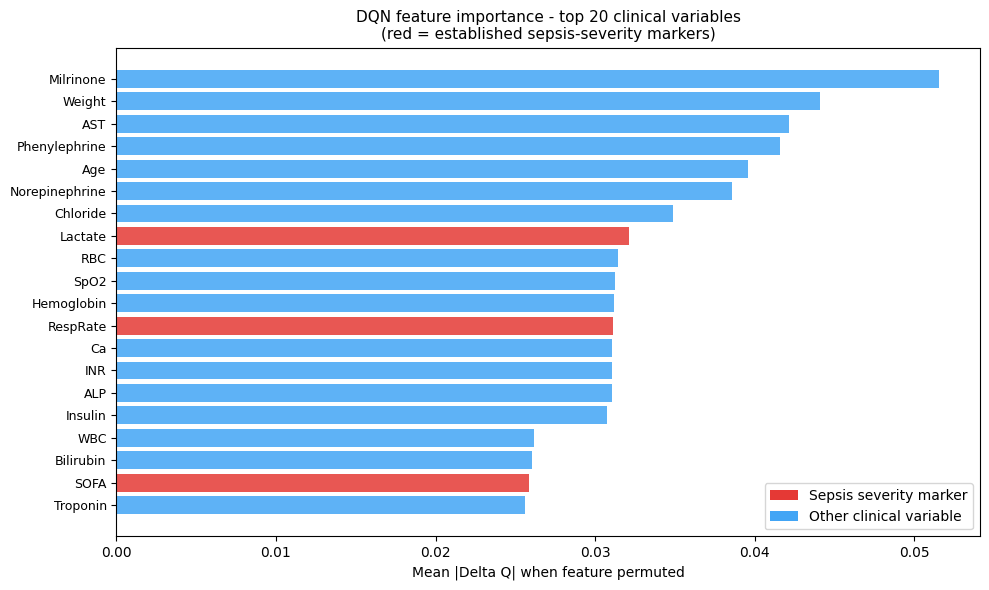

In [14]:
# Use the normalized DQN (dqn2_tag); importance is computed on the same
# normalized inputs the network saw during training.
importances, order = srl.feature_importance_dqn(dqn2_tag, n_states=500, top_n=20)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Saved outputs\configB_shap_importance.png
Top 10 features by SHAP:
   1. WBC              0.03707
   2. Lactate          0.02317 <- sepsis marker
   3. Age              0.02292
   4. RespRate         0.02243 <- sepsis marker
   5. RBC              0.02073
   6. Chloride         0.01991
   7. INR              0.01883
   8. Urine_Output     0.01795 <- sepsis marker
   9. Dopamine         0.01782
  10. Phenylephrine    0.01771


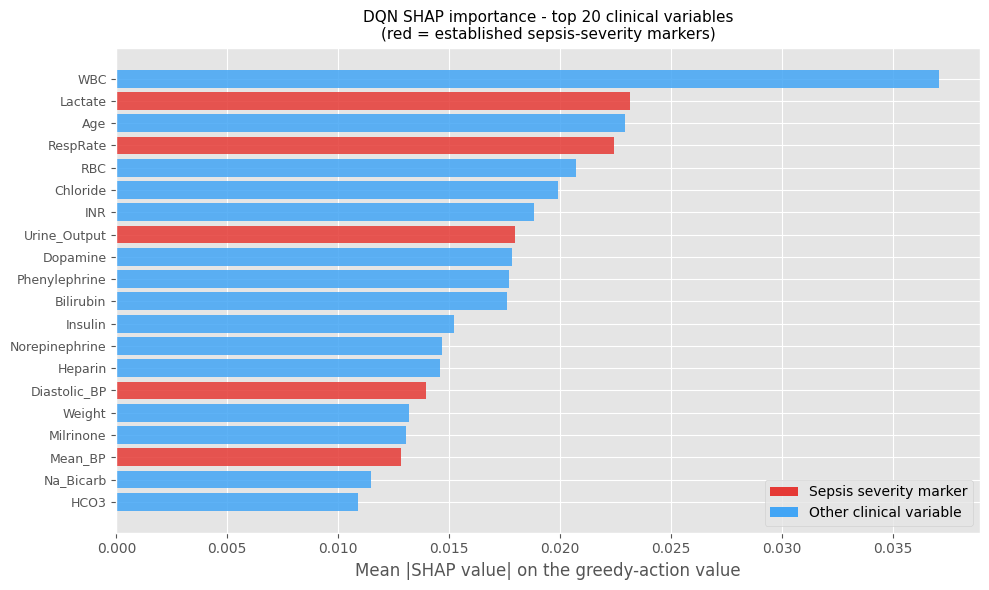

(array([0.00356827, 0.0096    , 0.00446334, 0.01061757, 0.0175842 ,
        0.00856786, 0.01990597, 0.00748139, 0.01394707, 0.00938443,
        0.00510705, 0.00655321, 0.00350915, 0.01090708, 0.00667514,
        0.01882519, 0.02316814, 0.0070348 , 0.01282957, 0.00597938,
        0.00780791, 0.00568856, 0.00777002, 0.00791497, 0.02073447,
        0.00877324, 0.00962443, 0.00721043, 0.00658778, 0.00459906,
        0.01794975, 0.03706647, 0.01319154, 0.00947653, 0.01459259,
        0.00438013, 0.01149455, 0.015236  , 0.01466948, 0.0084627 ,
        0.00333547, 0.01782061, 0.01770582, 0.00962991, 0.0130307 ,
        0.0224274 , 0.02292005]),
 array([31, 16, 46, 45, 24,  6, 15, 30, 41, 42,  4, 37, 38, 34,  8, 32, 44,
        18, 36, 13,  3, 43, 26,  1, 33,  9, 25,  5, 39, 23, 20, 22,  7, 27,
        17, 14, 28, 11, 19, 21, 10, 29,  2, 35,  0, 12, 40]))

In [23]:

srl.shap_importance_dqn('dqn_v2_1m', n_background=100, n_explain=300, top_n=20)

### 6.3 Honest Config A vs Config B comparison

Config A numbers are read from `configA_results.json` (produced by the Config A notebook) - never hard-coded. **Run the Config A notebook first.**

In [15]:
# Cross-config table using REAL Config A metrics from configA_results.json
df_compare = srl.compare_configs(results, configA_path='configA_results.json',
                                 condition='All')
df_compare

,Config,Agent,Return,Survival,Intensity
0,A,Random,0.5877,68.7%,0.494
1,A,Policy Iteration,0.7507,78.8%,0.163
2,A,Q-Learning,0.6115,71.3%,0.486
3,A,SARSA,0.6313,72.6%,0.462
4,B,DQN (v1),0.5742,64.7%,0.392
5,B,PPO (v1),0.5898,66.0%,0.406
6,B,DQN-v2,0.5590,65.1%,0.443
7,B,PPO-v2,0.5945,66.2%,0.407
8,B,A2C,0.6012,66.4%,0.374


### 6.4 Reward shaping - redirecting RL from *parsimony* to *survival*

**Diagnosis (the key finding).** Compared against a per-condition **random baseline**
on the same seeds, the unshaped deep agents barely improve *survival*: they mostly
learn to lower *treatment intensity* (which raises return via the `lam` penalty)
rather than to save more patients. The native reward is sparse (+1 at survival),
so the parsimony penalty is the only dense signal and the gradient follows it.

**Fix (theory + practice).** We add **potential-based reward shaping**
(Ng, Harada & Russell, 1999) with potential `Phi(s) = -beta * SOFA(s)`: transitions
that lower the SOFA organ-failure score get an immediate bonus. Potential-based
shaping provably leaves the optimal policy unchanged, so it is a principled way to
densify the signal (reward-design theme of Lab 6) without biasing the objective.

**Brief compliance.** Shaping is applied to the **training** env only
(`SofaShapingEnv`); evaluation always uses the unshaped `make_clinical_env()` and
the true reward, so reported numbers are on the required environment.

First, a **fair** random baseline bucketed by failure mode (same seed scheme as the agents) - this is what every agent must actually beat *per condition*.

In [16]:
# Fair, per-condition random baseline (replaces the overall-only baseline above)
rand_buckets = srl.random_baseline_by_condition(n_episodes=1000)
results['Random'] = rand_buckets          # include random as a group in comparisons

# Honest Config A vs Config B table, now WITH the bucketed Config B random
df_fair = srl.compare_configs(results, configA_path='configA_results.json', condition='All')
df_fair

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[random] All      n=1000  return=0.5573  survival=64.6%
[random] Clean    n= 672  return=0.6352  survival=72.2%
[random] Noisy    n= 125  return=0.5284  survival=63.2%
[random] Missing  n= 160  return=0.5493  survival=63.7%
[random] Acute    n=  91  return=-0.0866  survival=0.0%


,Config,Agent,Return,Survival,Intensity
0,A,Random,0.5877,68.7%,0.494
1,A,Policy Iteration,0.7507,78.8%,0.163
2,A,Q-Learning,0.6115,71.3%,0.486
3,A,SARSA,0.6313,72.6%,0.462
4,B,DQN (v1),0.5742,64.7%,0.392
5,B,PPO (v1),0.5898,66.0%,0.406
6,B,DQN-v2,0.5590,65.1%,0.443
7,B,PPO-v2,0.5945,66.2%,0.407
8,B,A2C,0.6012,66.4%,0.374
9,B,Random,0.5573,64.6%,0.494


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


Output()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


[ppo_v2_shaped] training complete (150,000 steps).
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[ppo_v2_shaped] All      n=1000  return=0.5671  survival=64.5%  intensity=0.442
[ppo_v2_shaped] Clean    n= 648  return=0.6457  survival=72.2%  intensity=0.439
[ppo_v2_shaped] Noisy    n= 172  return=0.5411  survival=62.2%  intensity=0.460
[ppo_v2_shaped] Missing  n= 149  return=0.5023  survival=57.7%  intensity=0.435
[ppo_v2_shaped] Acute    n=  91  return=-0.0762  survival=0.0%  intensity=0.452
                Agent  Survival % (All)
    Random (bucketed)              64.6
    PPO-v2 (unshaped)              66.2
PPO-v2 + SOFA shaping              64.5
Saved outputs\configB_shaping_survival.png


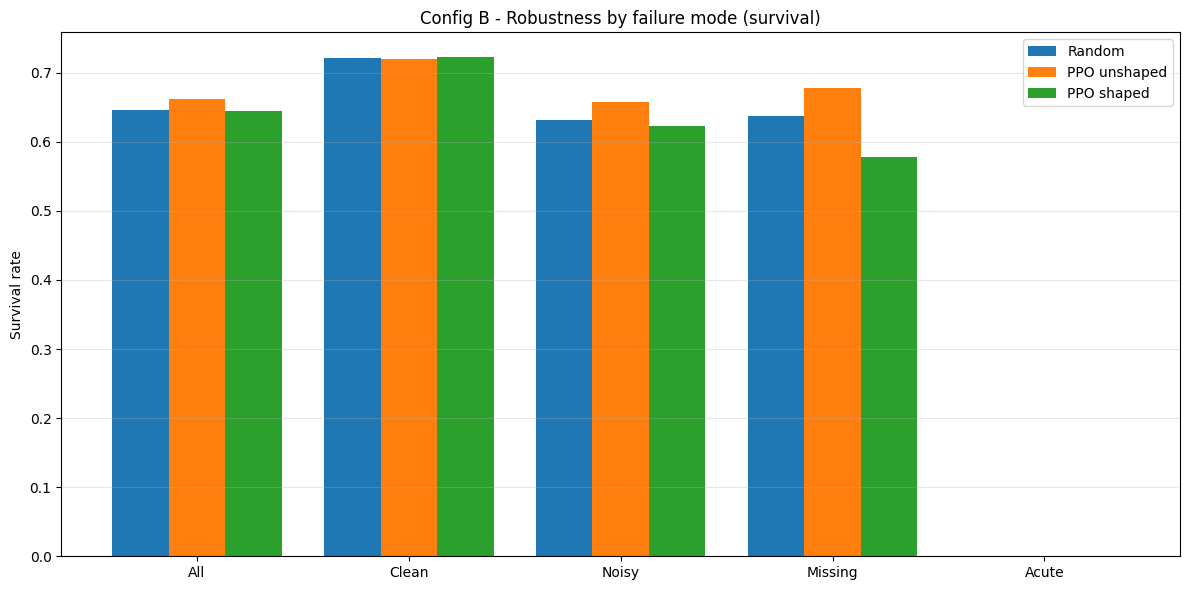

In [17]:
# Creative extension: SOFA reward shaping (training-only). Gated so you control runtime.
RUN_SHAPING = True   # set False to skip; uses the same TIMESTEPS budget as the others

if RUN_SHAPING:
    _, ppo_shaped_tag = srl.train_agent(
        'PPO', timesteps=TIMESTEPS, normalize=True,
        shaping=True, shaping_beta=0.05, tag='ppo_v2_shaped',
        eval_freq=EVAL_FREQ, n_eval_episodes=N_EVAL,
    )
    res_shaped = srl.evaluate_conditions(ppo_shaped_tag, 'PPO', n_episodes=1000)

    # Fair survival comparison: random vs unshaped PPO vs shaped PPO
    import pandas as pd
    def surv(r, b='All'): return round(r[b]['survival'] * 100, 1)
    df_shape = pd.DataFrame(
        [('Random (bucketed)',      surv(rand_buckets)),
         ('PPO-v2 (unshaped)',      surv(results['PPO-v2'])),
         ('PPO-v2 + SOFA shaping',  surv(res_shaped))],
        columns=['Agent', 'Survival % (All)'])
    print(df_shape.to_string(index=False))

    srl.plot_robustness(
        {'Random': rand_buckets, 'PPO unshaped': results['PPO-v2'], 'PPO shaped': res_shaped},
        metric='survival', baseline=None,
        filename='configB_shaping_survival.png')
else:
    print('Reward-shaping experiment skipped (RUN_SHAPING=False).')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[random] All      n=1000  return=0.5433  survival=63.1% (+/-3.0)  intensity=0.503
[random] Clean    n= 659  return=0.6081  survival=69.7% (+/-3.4)  intensity=0.502
[random] Noisy    n= 137  return=0.4635  survival=56.2% (+/-8.0)  intensity=0.505
[random] Missing  n= 157  return=0.6043  survival=68.8% (+/-7.0)  intensity=0.504
[random] Acute    n=  92  return=-0.0758  survival=0.0% (+/-0.0)  intensity=0.494
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[expert] All      n=1000  return=0.5734  survival=63.2% (+/-3.0)  intensity=0.304
[expert] Clean    n= 665  return=0.6322  survival=69.2% (+/-3.5)  intensity=0.297
[expert] Noisy    n= 148  return=0.5298  survival=58.1% (+/-7.8)  intensity=0.300
[expert] Missing  n= 153  return=0.5945  survival=65.4% (+/-7.2)  intensity=0.318
[expert] Acute    n=  76  return=-0.0606  

,Config,Agent,Return,Survival,Intensity
0,A,Random,0.5877,68.7%,0.494
1,A,Policy Iteration,0.7507,78.8%,0.163
2,A,Q-Learning,0.6115,71.3%,0.486
3,A,SARSA,0.6313,72.6%,0.462
4,B,Random,0.5433,63.1% +/- 3.0,0.503
5,B,Expert,0.5734,63.2% +/- 3.0,0.304
6,B,DQN-v2 1M,0.6148,67.7% +/- 2.9,0.369
7,B,PPO-v2 1M,0.6123,66.9% +/- 2.9,0.341
8,B,A2C 1M,0.6261,65.1% +/- 3.0,0.149


Saved outputs\configB_1m_robustness_survival.png


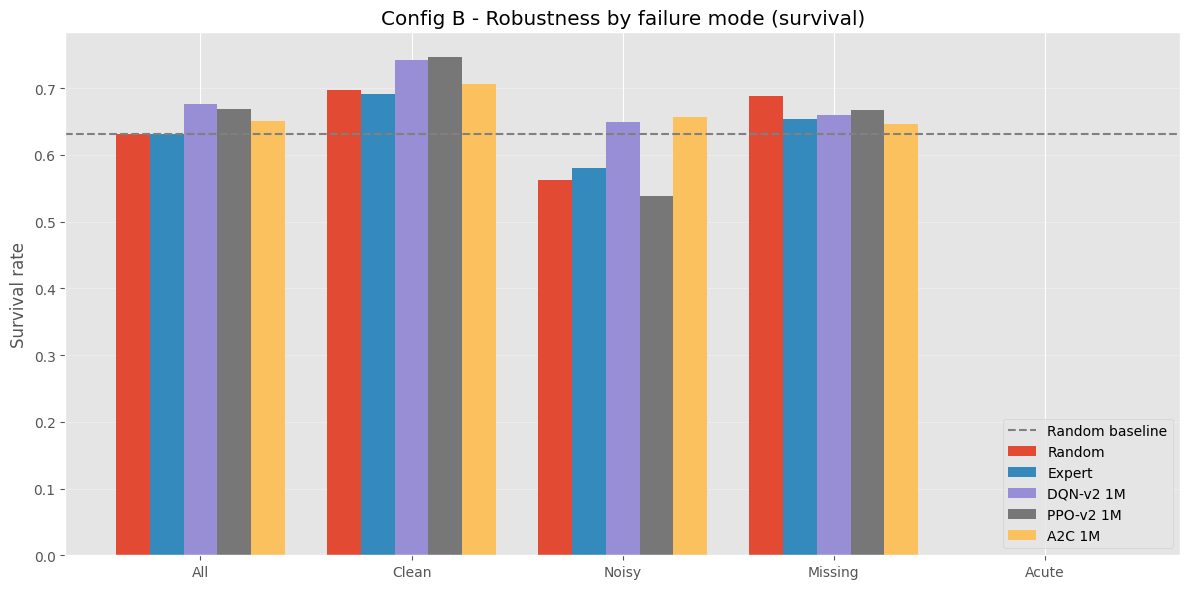

'outputs\\configB_1m_robustness_survival.png'

In [19]:
rand_buckets   = srl.random_baseline_by_condition(n_episodes=1000)
expert_buckets = srl.expert_baseline_by_condition(n_episodes=1000)
final = {
    'Random':    rand_buckets,
    'Expert':    expert_buckets,
    'DQN-v2 1M': srl.evaluate_conditions('dqn_v2_1m', 'DQN', n_episodes=1000),
    'PPO-v2 1M': srl.evaluate_conditions('ppo_v2_1m', 'PPO', n_episodes=1000),
    'A2C 1M':    srl.evaluate_conditions('a2c_v2_1m', 'A2C', n_episodes=1000),
}
display(srl.compare_configs(final))
srl.plot_robustness(final, metric='survival',
                    baseline=rand_buckets['All']['survival'],
                    filename='configB_1m_robustness_survival.png')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
  BC epoch  10  loss=1.6422  train_acc=0.428
  BC epoch  20  loss=1.6111  train_acc=0.434
  BC epoch  30  loss=1.5885  train_acc=0.443
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
[bc] All      n=1000  return=0.5946  survival=64.2% (+/-2.9)  intensity=0.258
[bc] Clean    n= 669  return=0.6551  survival=70.3% (+/-3.4)  intensity=0.250
[bc] Noisy    n= 135  return=0.5963  survival=63.7% (+/-8.1)  intensity=0.269
[bc] Missing  n= 152  return=0.6135  survival=66.4% (+/-7.6)  intensity=0.268
[bc] Acute    n=  93  return=-0.0454  survival=0.0% (+/-0.0)  intensity=0.292
Saved outputs\configB_bc_survival.png


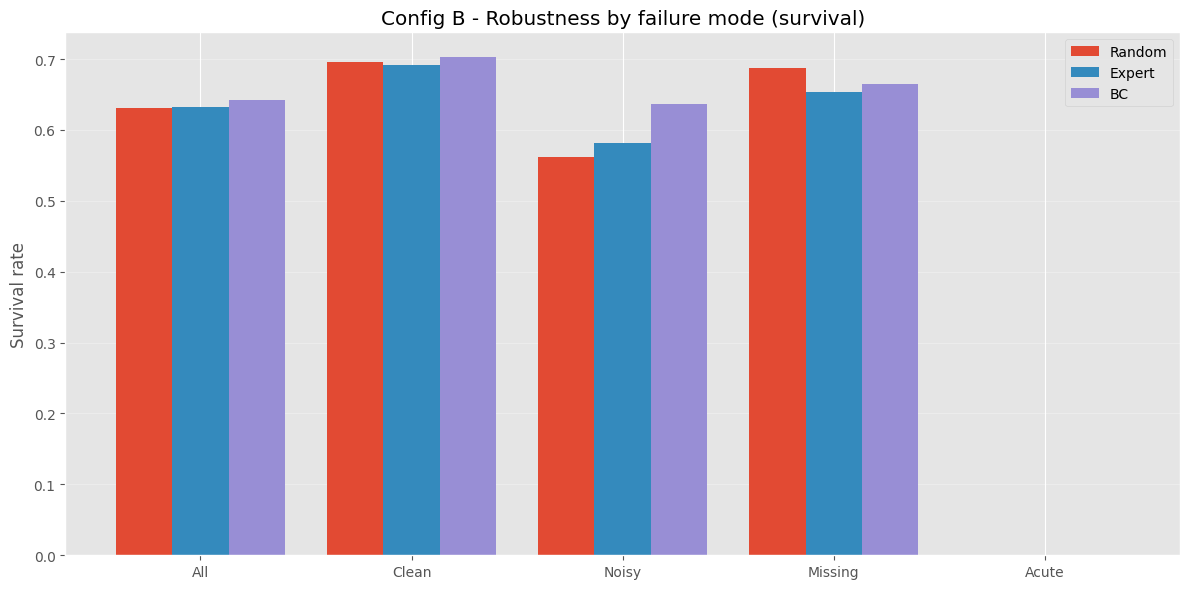

,Config,Agent,Return,Survival,Intensity
0,A,Random,0.5877,68.7%,0.494
1,A,Policy Iteration,0.7507,78.8%,0.163
2,A,Q-Learning,0.6115,71.3%,0.486
3,A,SARSA,0.6313,72.6%,0.462
4,B,Random,0.5433,63.1% +/- 3.0,0.503
5,B,Expert,0.5734,63.2% +/- 3.0,0.304
6,B,BC (imitation),0.5946,64.2% +/- 2.9,0.258


In [22]:
X, y = srl.collect_expert_demonstrations(n_episodes=4000)
bc = srl.train_bc(X, y, epochs=30)
bc_res = srl.evaluate_bc(bc, n_episodes=1000)
srl.plot_robustness({'Random': rand_buckets, 'Expert': expert_buckets, 'BC': bc_res},
                    metric='survival', filename='configB_bc_survival.png')
display(srl.compare_configs({'Random':rand_buckets,'Expert':expert_buckets,'BC (imitation)':bc_res}))